# Zadanie 1
## Klasyfikacja Absorbcja/Dystrybucja

| Task | Description |
|------|-------------|
| hia_hou | Absorption |
| bioavailability_ma | Absorption |
| bbb_martins | Distribution |

Brak wspólnych smiles bbb_martins i hia_hou

### Analiza statystyczna


In [2]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt

import random_forest_model
# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['hia_hou', 'bioavailability_ma', 'bbb_martins']
df = df[df['task'].isin(tasks)]

df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [3]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
bbb_martins           2030
bioavailability_ma     640
hia_hou                578
Name: count, dtype: int64
Średnia liczba zadań na smiles: 1.16


,task,bbb_martins,bioavailability_ma,hia_hou,mean,count,std
0,bbb_martins,1975,293,90,0.764039,2030,0.424702
1,bioavailability_ma,293,640,129,0.768750,640,0.421962
2,hia_hou,90,129,578,0.865052,578,0.341964


In [4]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')

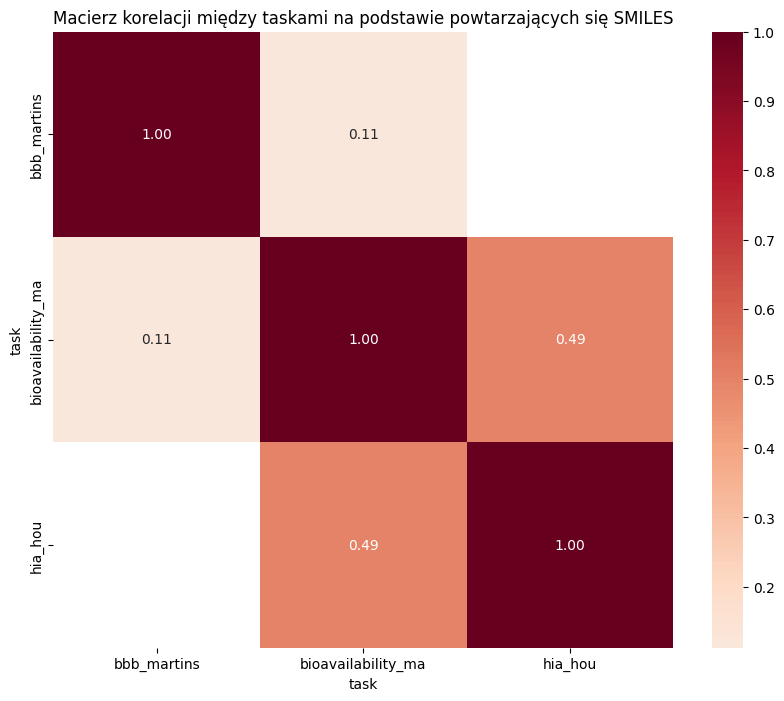

In [5]:
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

NaN wynika z braku wariancji w części wspólnej hia_hou (absorbcja) i bbb_martins (dystrybucja). W każdym przypadku jeśli badano oba związki to absorbcja wynosiła True.

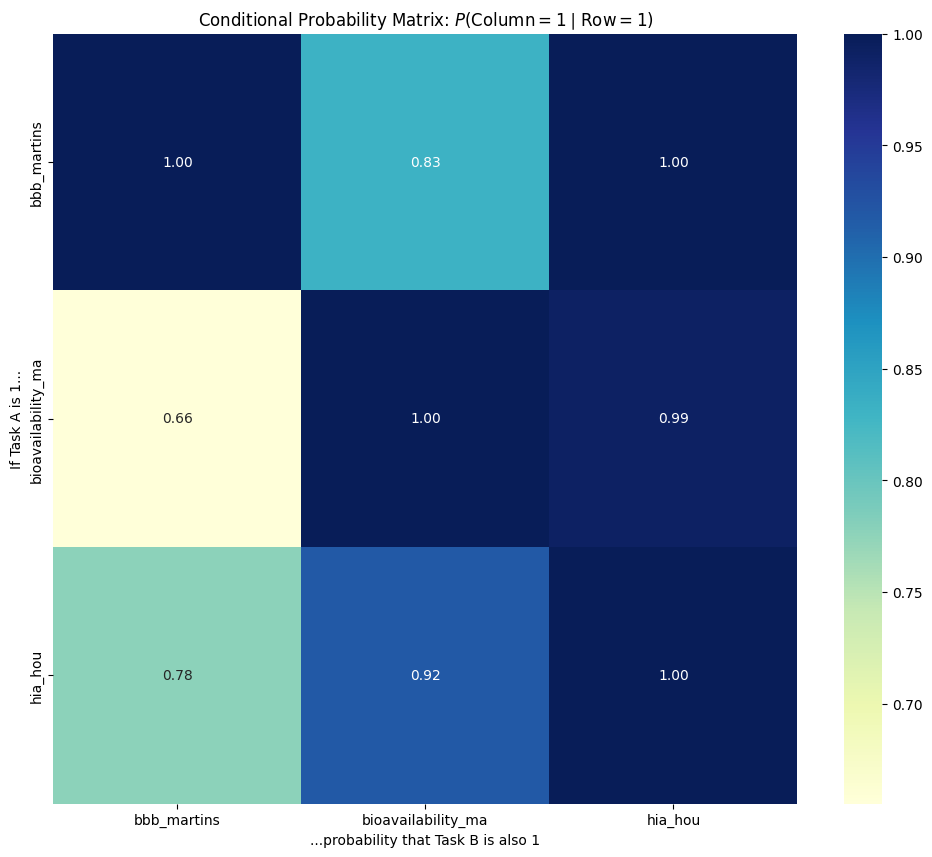

In [6]:
ones_mask = (df_wide == 1).astype(int)
intersection_11 = ones_mask.T @ ones_mask

valid_mask = df_wide.notna().astype(int)
intersection_1x = ones_mask.T @ valid_mask

cond_prob = intersection_11 / intersection_1x

plt.figure(figsize=(12, 10))
sns.heatmap(cond_prob, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Conditional Probability Matrix: $P(\\text{Column}=1 \\mid \\text{Row}=1)$")
plt.ylabel("If Task A is 1...")
plt.xlabel("...probability that Task B is also 1")
plt.show()

### Random Forest

In [7]:
summary_df = random_forest_model.run_single_task_pipeline(df, tasks)
summary_df['SOTA'] = ['0.989±0.001', '0.748±0.033', '0.916±0.001']
summary_df['MTL auc'] = [' 0.8835', '0.6722', '0.9759']

# bbb_martins: 0.8835
# bioavailability_ma: 0.6722
# hia_hou: 0.9759
summary_df


--- Top 15 najważniejszych cech dla hia_hou ---
            feature  importance
                qed    0.050851
               TPSA    0.048510
            NOCount    0.031310
          NHOHCount    0.028523
            MolLogP    0.027936
         NumHDonors    0.027043
              MolWt    0.024547
      NumHAcceptors    0.024187
           BalabanJ    0.020982
          LabuteASA    0.020573
              MolMR    0.020276
NumValenceElectrons    0.016356
            bit_628    0.015131
   MaxPartialCharge    0.013070
            bit_414    0.012329

--- Top 15 najważniejszych cech dla bioavailability_ma ---
            feature  importance
                qed    0.023362
               TPSA    0.021596
NumValenceElectrons    0.020476
              MolMR    0.019032
          LabuteASA    0.018737
              MolWt    0.017683
   MaxPartialCharge    0.016987
            MolLogP    0.016804
         NumHDonors    0.014577
MaxAbsPartialCharge    0.013753
           BalabanJ    0.01

,task,auc,acc,f1,SOTA,MTL auc
0,hia_hou,0.946555,0.905172,0.946341,0.989±0.001,0.8835
1,bioavailability_ma,0.687865,0.726562,0.834123,0.748±0.033,0.6722
2,bbb_martins,0.904258,0.864532,0.914463,0.916±0.001,0.9759



SOTA results from paper "Quantum Enhanced MTL ...".


In our model used RandomForestClassifier from scikit with 200 estimators.

### MTL model

Start treningu na cuda. Ilość cech: 1066, Ilość zadań: 3
Epoch 00 | Train Loss: 0.5125 | Val Loss: 0.2721 | Avg Val AUC: 0.8597
Epoch 01 | Train Loss: 0.3358 | Val Loss: 0.2212 | Avg Val AUC: 0.8622
Epoch 02 | Train Loss: 0.2664 | Val Loss: 0.2188 | Avg Val AUC: 0.8710
Epoch 03 | Train Loss: 0.2204 | Val Loss: 0.2116 | Avg Val AUC: 0.8717
Epoch 04 | Train Loss: 0.1822 | Val Loss: 0.2025 | Avg Val AUC: 0.8682
Epoch 05 | Train Loss: 0.1451 | Val Loss: 0.2025 | Avg Val AUC: 0.8711
Epoch 06 | Train Loss: 0.1182 | Val Loss: 0.2280 | Avg Val AUC: 0.8595
Epoch 07 | Train Loss: 0.0868 | Val Loss: 0.2494 | Avg Val AUC: 0.8616
Epoch 08 | Train Loss: 0.0783 | Val Loss: 0.2585 | Avg Val AUC: 0.8696
Epoch 09 | Train Loss: 0.0661 | Val Loss: 0.2591 | Avg Val AUC: 0.8694
Epoch 10 | Train Loss: 0.0458 | Val Loss: 0.2740 | Avg Val AUC: 0.8581
Epoch 11 | Train Loss: 0.0358 | Val Loss: 0.3043 | Avg Val AUC: 0.8575
Epoch 12 | Train Loss: 0.0351 | Val Loss: 0.3450 | Avg Val AUC: 0.8552
Epoch 13 | Train Los

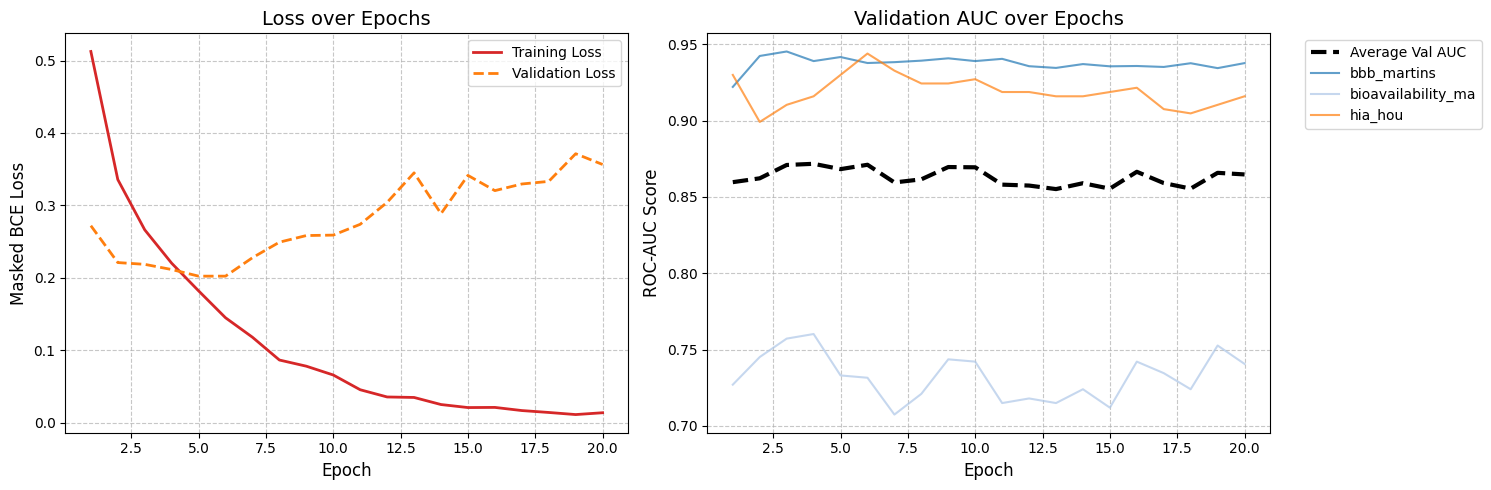


--- FINAL TEST AUC ---
bbb_martins: 0.8783
bioavailability_ma: 0.6743
hia_hou: 0.9709

--- FEATURE IMPORTANCE ---
            feature  importance
           fr_ester    0.017398
             fr_COO    0.008333
             fr_NH2    0.008041
                qed    0.007749
              MolMR    0.007456
          fr_phenol    0.006287
            bit_428    0.006287
              MolWt    0.005994
NumValenceElectrons    0.005848
               TPSA    0.005629
         fr_halogen    0.005336
            bit_193    0.005263
            bit_173    0.005117
   MinPartialCharge    0.004825
            bit_249    0.004678
            bit_583    0.004532
            bit_270    0.004532
            bit_301    0.004386
            bit_952    0.004386
          homo_lumo    0.004313
            bit_624    0.004240
            bit_767    0.004020
            bit_548    0.003947
            bit_633    0.003947
            bit_251    0.003801


In [8]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from mtl_utils import (
    prepare_mtl_data, MTLDataset, MTLNet,
    train_epoch, evaluate, permutation_importance_mtl
)

X_all, y_all, mask_all, tasks, splits, feat_names = prepare_mtl_data(df)

train_idx = splits == 'train'
val_idx = splits == 'valid'
test_idx = splits == 'test'

train_loader = DataLoader(MTLDataset(X_all[train_idx], y_all[train_idx], mask_all[train_idx]), batch_size=128, shuffle=True)
val_loader = DataLoader(MTLDataset(X_all[val_idx], y_all[val_idx], mask_all[val_idx]), batch_size=128)
test_loader = DataLoader(MTLDataset(X_all[test_idx], y_all[test_idx], mask_all[test_idx]), batch_size=128)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MTLNet(X_all.shape[1], len(tasks)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Start treningu na {device}. Ilość cech: {X_all.shape[1]}, Ilość zadań: {len(tasks)}")

# Słownik wzbogacony o val_loss
history = {'loss': [], 'val_loss': [], 'val_aucs': []}

for epoch in range(20):
    train_loss = train_epoch(model, train_loader, opt, device)

    # Odbieramy teraz też val_loss
    val_loss, val_aucs = evaluate(model, val_loader, device, tasks)

    # Zapisujemy do historii
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_aucs'].append(val_aucs)

    avg_val_auc = np.nanmean(list(val_aucs.values()))
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Avg Val AUC: {avg_val_auc:.4f}")


# --- FUNKCJA DO WYKRESÓW ---
def plot_training_history(history, tasks):
    epochs = range(1, len(history['loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Wykres 1: Training vs Validation Loss ---
    ax1.plot(epochs, history['loss'], color='tab:red', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], color='tab:orange', label='Validation Loss', linewidth=2, linestyle='--')

    ax1.set_title('Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Masked BCE Loss', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # --- Wykres 2: Validation AUC ---
    avg_aucs = [np.nanmean(list(epoch_aucs.values())) for epoch_aucs in history['val_aucs']]
    ax2.plot(epochs, avg_aucs, 'k--', label='Average Val AUC', linewidth=3, zorder=10)

    cmap = plt.get_cmap('tab20')
    for i, task in enumerate(tasks):
        task_aucs = [epoch_aucs[task] for epoch_aucs in history['val_aucs']]
        ax2.plot(epochs, task_aucs, label=task, color=cmap(i), alpha=0.7, linewidth=1.5)

    ax2.set_title('Validation AUC over Epochs', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('ROC-AUC Score', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# --- WYZWALAMY WYKRES I TEST KOŃCOWY ---
plot_training_history(history, tasks)

test_loss, test_aucs = evaluate(model, test_loader, device, tasks)
print("\n--- FINAL TEST AUC ---")
for t, v in test_aucs.items():
    print(f"{t}: {v:.4f}")

print("\n--- FEATURE IMPORTANCE ---")
imp_df = permutation_importance_mtl(model, test_loader, device, feat_names)
print(imp_df.head(25).to_string(index=False))